<a href="https://colab.research.google.com/github/shivammishra000/AI-ML-Concepts/blob/main/age_gender_revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [2]:
import shutil

destination = "/content/utkface-new"
shutil.copytree(path, destination, dirs_exist_ok=True)

print("Copied to:", destination)

Copied to: /content/utkface-new


In [3]:
import os
import numpy as np
import pandas as pd
from  tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
folder_path = '/content/utkface-new/utkface_aligned_cropped/UTKFace'

In [5]:
age=[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
  age.append(int(file.split('_')[0]))
  gender.append(int(file.split('_')[1]))
  img_path.append(file)

In [6]:
len(age)

23708

In [7]:
df = pd.DataFrame({'age':age,'gender':gender,'img':img_path})

In [8]:
df.shape

(23708, 3)

In [9]:
df.head()

,age,gender,img
0,1,0,1_0_0_20161219190824794.jpg.chip.jpg
1,48,0,48_0_0_20170117183518783.jpg.chip.jpg
2,26,1,26_1_1_20170112211356292.jpg.chip.jpg
3,37,0,37_0_0_20170117135950641.jpg.chip.jpg
4,33,1,33_1_0_20170105163852244.jpg.chip.jpg


In [10]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [11]:
train_df.shape

(20000, 3)

In [12]:
test_df.shape

(3708, 3)

In [13]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    directory=folder_path,
                                                    x_col='img',
                                                    y_col=['age','gender'],
                                                    target_size=(200,200),
                                                    class_mode='multi_output')

test_generator = test_datagen.flow_from_dataframe(test_df,
                                                  directory=folder_path,
                                                  x_col='img',
                                                  y_col=['age','gender'],
                                                  target_size=(200,200),
                                                  class_mode='multi_output')

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [15]:
x, y = next(train_generator)

print(type(x))
print(type(y))
print(y)

<class 'numpy.ndarray'>
<class 'list'>
[array([52, 27, 12, 25, 15, 30, 38, 15, 14, 26, 50, 24, 35, 24, 52, 23, 30,
        1, 24, 82,  2, 36, 45, 37, 41, 20, 50, 10, 39, 40, 28, 54]), array([0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0])]


In [16]:
from keras.applications.resnet50 import ResNet50
from keras.layers import *
from keras.models import Model

In [17]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [18]:
resnet = ResNet50(include_top=False, input_shape=(200,200,3))

resnet.trainable=False

output = resnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512, activation='relu')(flatten)
dense2 = Dense(256, activation='relu')(flatten)

dense3 = Dense(512, activation='relu')(dense1)
dense4 = Dense(256, activation='relu')(dense2)

output1 = Dense(1, activation='linear', name='age')(dense3)
output2 = Dense(1, activation='sigmoid', name='gender')(dense4)

In [19]:
model = Model(inputs=resnet.input,outputs=[output1,output2])

In [20]:
model.compile(optimizer='adam', loss={'age': 'mae', 'gender': 'binary_crossentropy'},
             metrics={'age': 'mae', 'gender': 'accuracy'},
             loss_weights={'age': 1, 'gender': 99})

In [21]:
def wrap_generator(gen):
    while True:
        x, y = next(gen)
        yield x, {
            "age": y[0],
            "gender": y[1]
        }

train_gen = wrap_generator(train_generator)
test_gen = wrap_generator(test_generator)

model.fit(
    train_gen,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_data=test_gen,
    validation_steps=len(test_generator)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 386ms/step - age_loss: 15.5489 - age_mae: 15.5489 - gender_accuracy: 0.5145 - gender_loss: 0.7798 - loss: 92.7500 - val_age_loss: 14.8335 - val_age_mae: 14.8311 - val_gender_accuracy: 0.5218 - val_gender_loss: 0.6922 - val_loss: 83.3620
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 236s 377ms/step - age_loss: 15.0527 - age_mae: 15.0527 - gender_accuracy: 0.5225 - gender_loss: 0.6924 - loss: 83.5956 - val_age_loss: 14.5455 - val_age_mae: 14.5468 - val_gender_accuracy: 0.5194 - val_gender_loss: 0.6924 - val_loss: 83.0984
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 352ms/step - age_loss: 14.9500 - age_mae: 14.9500 - gender_accuracy: 0.5232 - gender_loss: 0.6921 - loss: 83.4727 - val_age_loss: 14.9539 - val_age_mae: 14.9539 - val_gender_accuracy: 0.5199 - val_gender_loss: 0.6925 - val_loss: 83.5136
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 221s 354ms/step - age_loss: 14.9090 - age_mae: 14.9090 - gender_accuracy: 0.5224 - gender_loss: 0.6922 - loss: 83.

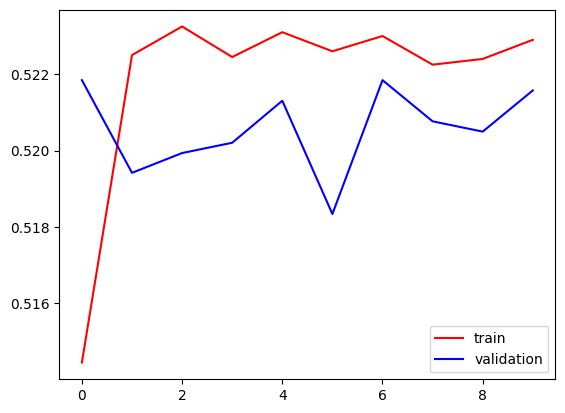

In [22]:
import matplotlib.pyplot as plt

plt.plot(model.history.history['gender_accuracy'],color='red',label='train')
plt.plot(model.history.history['val_gender_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()